<a href="https://colab.research.google.com/github/Light466/My_Programs/blob/main/CNN_cat_dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [3]:
!pip install -q datasets

In [4]:
from datasets import load_dataset

dataset = load_dataset("microsoft/cats_vs_dogs")

print(dataset)

README.md:   0%|          | 0.00/8.16k [00:00<?, ?B/s]

data/train-00000-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  330MB            

data/train-00000-of-00002.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  391MB            

data/train-00001-of-00002.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/23410 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'labels'],
        num_rows: 23410
    })
})


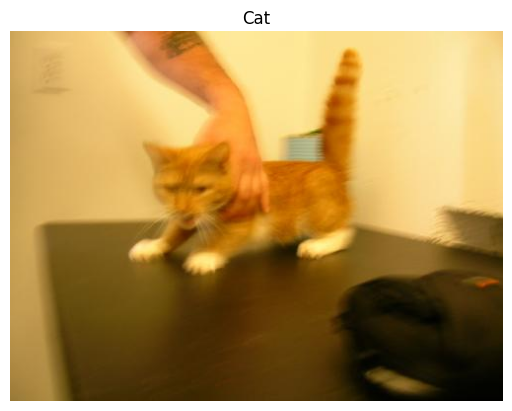

In [5]:
import matplotlib.pyplot as plt

image = dataset["train"][0]["image"]
label = dataset["train"][0]["labels"]

plt.imshow(image)

if label == 0:
    plt.title("Cat")
else:
    plt.title("Dog")

plt.axis("off")
plt.show()

In [6]:
import numpy as np

IMG_SIZE = 64

x = []
y = []

for item in dataset["train"]:

    image = item["image"].convert("RGB")
    image = image.resize((IMG_SIZE, IMG_SIZE))

    x.append(np.array(image))
    y.append(item["labels"])

x = np.array(x)
y = np.array(y)

print("Images:", x.shape)
print("Labels:", y.shape)

Images: (23410, 64, 64, 3)
Labels: (23410,)


In [7]:
x = x.astype("float32") / 255.0

In [8]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

Training images: (18728, 64, 64, 3)
Testing images: (4682, 64, 64, 3)


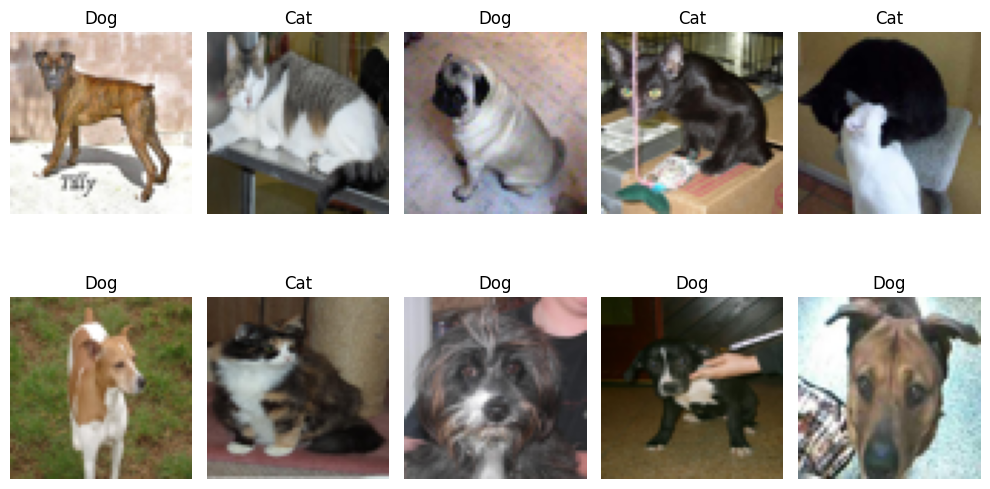

In [9]:
plt.figure(figsize=(10, 6))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(x_train[i])

    if y_train[i] == 0:
        title = "Cat"
    else:
        title = "Dog"

    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
import tensorflow as tf

model = tf.keras.Sequential([

    # First convolution
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(64, 64, 3)
    ),

    # Pooling
    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Second convolution
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    # Pooling
    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Third convolution
    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    # Pooling
    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Convert feature maps into vector
    tf.keras.layers.Flatten(),

    # Fully connected layer
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    # Output layer
    # 1 = binary classification
    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [17]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 122s 462ms/step - accuracy: 0.8701 - loss: 0.3022 - val_accuracy: 0.8163 - val_loss: 0.3928
Epoch 2/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 122s 463ms/step - accuracy: 0.8881 - loss: 0.2589 - val_accuracy: 0.8388 - val_loss: 0.3777
Epoch 3/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 121s 457ms/step - accuracy: 0.9098 - loss: 0.2178 - val_accuracy: 0.8388 - val_loss: 0.3685
Epoch 4/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 123s 467ms/step - accuracy: 0.9268 - loss: 0.1786 - val_accuracy: 0.8441 - val_loss: 0.4119
Epoch 5/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 143s 470ms/step - accuracy: 0.9416 - loss: 0.1468 - val_accuracy: 0.8441 - val_loss: 0.4361
Epoch 6/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 123s 465ms/step - accuracy: 0.9595 - loss: 0.1030 - val_accuracy: 0.8473 - val_loss: 0.4677
Epoch 7/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 122s 461ms/step - accuracy: 0.9657 - loss: 0.0918 - val_accuracy: 0.8366 - val_loss: 0.5508
Epoch 8/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 123s 467ms/step - accuracy: 0.9784 -

In [18]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

147/147 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - accuracy: 0.8212 - loss: 0.7510
Test Accuracy: 0.8212302327156067


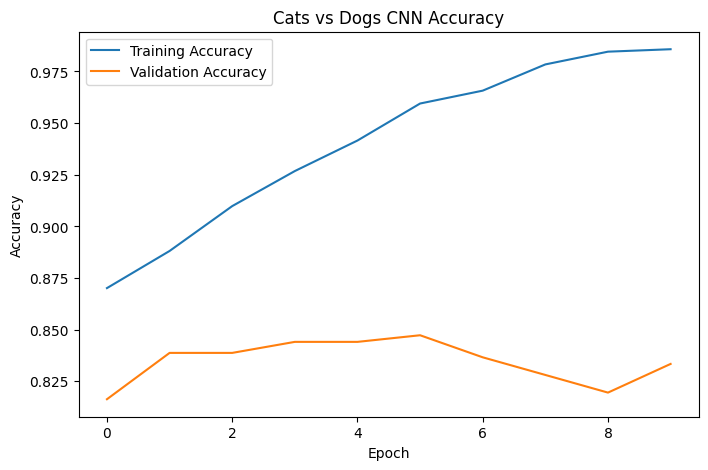

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Cats vs Dogs CNN Accuracy")

plt.legend()

plt.show()

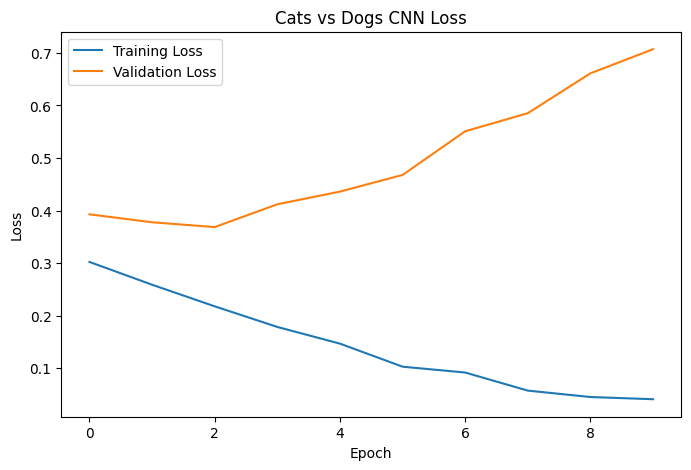

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Cats vs Dogs CNN Loss")

plt.legend()

plt.show()

In [22]:
index = 10

prediction = model.predict(
    x_test[index:index+1],
    verbose=0
)

probability = prediction[0][0]

if probability >= 0.5:
    predicted = "Dog"
else:
    predicted = "Cat"

if y_test[index] == 1:
    actual = "Dog"
else:
    actual = "Cat"

print("Actual:", actual)
print("Predicted:", predicted)
print("Probability:", probability)

Actual: Cat
Predicted: Cat
Probability: 0.26083487


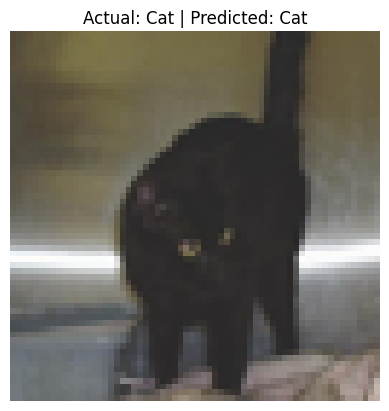

In [23]:
plt.imshow(x_test[index])

plt.title(
    "Actual: " + actual +
    " | Predicted: " + predicted
)

plt.axis("off")
plt.show()

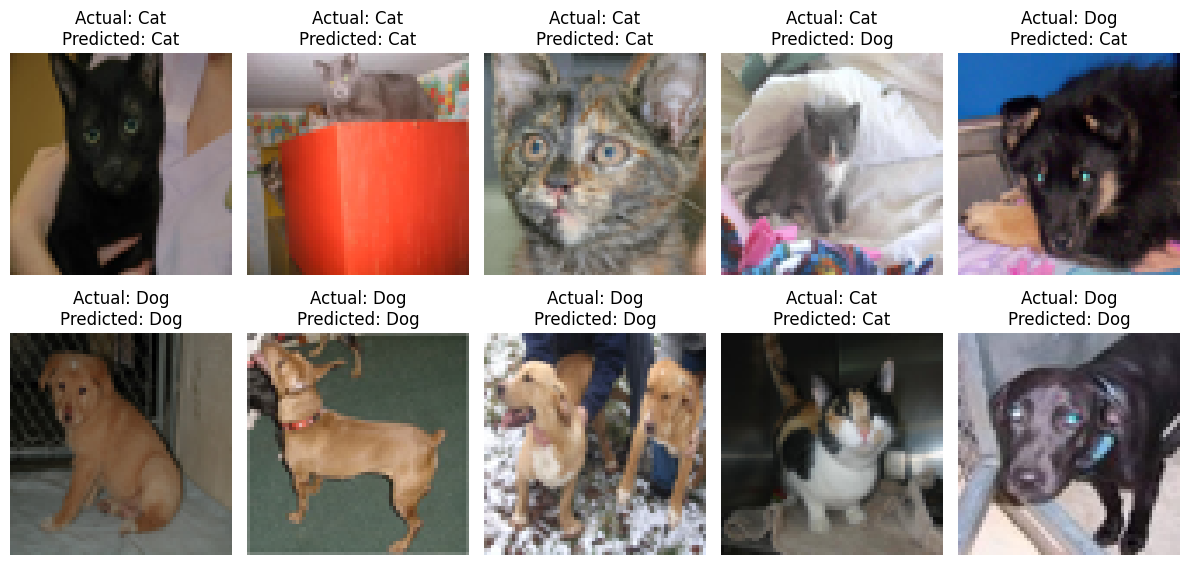

In [24]:
predictions = model.predict(
    x_test[:10],
    verbose=0
)

plt.figure(figsize=(12, 6))

for i in range(10):

    if predictions[i][0] >= 0.5:
        predicted = "Dog"
    else:
        predicted = "Cat"

    if y_test[i] == 1:
        actual = "Dog"
    else:
        actual = "Cat"

    plt.subplot(2, 5, i + 1)

    plt.imshow(x_test[i])

    plt.title(
        "Actual: " + actual +
        "\nPredicted: " + predicted
    )

    plt.axis("off")

plt.tight_layout()
plt.show()